# Lab 04: Graphical Models and D-Separation

_Note: Questions marked with (*) can be presented in the exercise sessions for up to 1 bonus point._

<hr>

We saw in the lecture that the conditional independence properties of a distribution that factorizes over a directed acyclic graph (DAG) can be deduced from properties of the graph. We introduced the concept of D-separation as a necessary and sufficient condition on the graph to have independence of a set of variables $X_A$ to another set $X_B$ conditionally to $X_C$. 

The purpose of this lab is to implement two methods to verify this conditional independence.

## Detection of Cardiovascular Diseases

We consider the following graphical model describing relations between different cardiovascular diseases.

![alt text](cardiovascular.jpg)

(Image source: https://bmjopen.bmj.com/content/10/5/e035867)

#### Question 1 (*)
a) Show that "Hypertension" is independent of "Has a chronic condition". <br>
b) Are the variables "Current smoker" and "Has a chronic condition" dependent or independent? Does it change when conditioned on "History of high cholesterol"?

### <font color='green'><u>Solution</u></font>
a) Each chain from "Hypertension" to "Has a chronic condition" has to pass through either "ever had blood cholesterol measured" and "history of high cholesterol". The possible chains would all have to end in one of the following ways:
* smoker $\rightarrow$ blood cholesterol measured $\leftarrow$ chronic condition
* blood cholesterol measured $\rightarrow$ high cholesterol $\leftarrow$ chronic condition
* CVD risk $\rightarrow$ high cholesterol $\leftarrow$ chronic condition
* CVD risk $\rightarrow$ high cholesterol $\leftarrow$ blood cholesterol measured $\leftarrow$ chronic condition

All of these involve V-structures. Since we have no conditioning variables, every chain is blocked and, by the Global Markov property, the two variables are independent in every distribution that factorizes over this graph.

b) Without conditioning, we can use a similar argument as above to show that the two variables are independent.

Once conditioned on "history of high cholesterol", the chain

* smoker $\rightarrow$ blood cholesterol measured $\leftarrow$ chronic condition

is no longer blocked, because a descendant of the middle node, "history of high cholesterol" is contained in the set of conditioning variables $C$. In fact, all chains are no longer blocked, but we only need one in order to show dependence.

<hr>

Note that in the previous questions, it was not necessary to know the distribution, just that it factorizes over the graph.

## Implementation of an Algorithm for D-separation

In [1]:
from dag import DAGNode, DAG, parse_graph
from typing import Collection

### Directed Acyclic Graphs

Consider the `DAGNode` and `DAG`. A `DAGNode` has the following fields:
```python
name: str
children: set[DAGNode]
parents: set[DAGNode]
```
Meanwhile, a `DAG` consists of the following fields:
```python
V: dict[str, DAGNode]
roots: list[str]
```

The function `parse_graph` can be used to quickly create a DAG by providing a list of edges.

Usage notes:
* Statements are separated by `;`.
* Each statement defines a sequence of edges.
* `(n1, n2) -> (n3, n4, n5)` create edges from both `n1` and `n2` to all of `n3`, `n4` and `n5`, so 6 edges in total. This can be extended to arbitrarily many nodes.
* `n1` is short for `(n1)`.
* You can use arbitrary names for nodes, so long as they do not contain any of `;`, `->` or `,`.

Example usage:
```python
g = parse_graph('X1 -> (X2, X5); X2 -> X3 -> X4 -> X7; X5 -> X6 -> X7')
```
This creates the below DAG (also on slide 18 of Lecture 4).

<div>
<img src="graph.png" width="500"/>
</div>

#### Question 2
Consider the DAG corresponding to $A \leftarrow B \rightarrow C \rightarrow D$.<br>
a) Implement it using the `parse_graph` method.<br>
b) Do we have that $A$ is independent of $D$ given $B$?

### <font color='green'><u>Solution</u></font>
a)

In [2]:
g = parse_graph('B -> (A, C); C -> D')

# Alternative solution:
g = parse_graph('B -> A; B -> C -> D')

b) Yes: $$p(a \mid d, b) = \frac{p(a, b, d)}{p(b, d)} = \frac{p(b)p(a \mid b) \sum_{c} p(c \mid b) p(d \mid c)}{p(b) \sum_{a,c} p(a \mid b) p(c \mid b) p(d \mid c)} = \frac{p(a \mid b)\sum_{c} p(c \mid b) p(d \mid c)}{\sum_{a,c} p(a \mid b) p(c \mid b) p(d \mid c)} = \frac{p(a \mid b)\sum_{c} p(c \mid b) p(d \mid c)}{\left(\sum_a p(a \mid b)\right) \left(\sum_{c} p(c \mid b) p(d \mid c)\right)} = p(a \mid b).$$

Alternatively, we can argue with chains: The only chain from $A$ to $D$ contains $B$. Since $B$ is neither in the middle of a V-structure, nor the descendant of a V-structure on the chain, the chain is blocked.

Finally, we could also argue using separation in undirected graphs: Since the model contains no V-structure, the distributions that factorize over it are the same that factorize over its symmetrization. In the undirected graph $A - B - C - D$, the nodes $A$ and $D$ are clearly separated by $B$.

### Blocked chains
Let $G = (V,E)$ be a DAG. Denote the descendants of a node $v \in V$ by $\mathsf{desc}(v)$.
Recall the following notions from the lecture:

A *chain* from $a$ to $b$ is a sequence of nodes $(v_0,v_1,\dots,v_n)$ with $v_0=a$ and $v_n=b$ that form a simple (i.e. without repeating nodes) path in the undirected graph induced by $G$.

A chain is said to be *blocked* by $C \subset V$, if either of the following two conditions is fulfilled:

1. there is a V-structure, $v_{i-1} \rightarrow v_i \leftarrow v_{i+1}$ and neither $v_i$ nor any of its descendants are in $C$: $$(\{v_i\} \cup \mathsf{desc}(v_i)) \cap C = \varnothing,$$
2. one of the nodes in the chain that is not part of a V-structure is contained in $C$: there is an $i \in \{1,\dots,n-1\}$ such that $v_i \in C$ and we do not have $v_{i-1} \rightarrow v_i \leftarrow v_{i+1}$.

In general, for mutually disjoint sets $A,B,C \subset V$, we say that $A$ and $B$ are d-separated by $C$, if **all chains** between members of $A$ and $B$ are blocked by $C$.

#### Question 3 (*)
a) Extend the implementation of `DAGNode` in the file `dag.py` by a function for computing its descendants. The return type should be `set[DAGNode]`.<br>
b) Implement the function `is_blocked_chain(g: DAG, chain: list[str], C: set[str]) -> bool` which should return whether the given chain is blocked by $C$.

### <font color='green'><u>Solution</u></font>
a)
```python
def descendants(self) -> set[DAGNode]:
    return self.children | set(child.descendants() for child in self.children)
```

b) 

In [3]:
def is_blocked_chain(chain: list[DAGNode], C: set[DAGNode]) -> bool:
    for l,m,r in zip(chain, chain[1:], chain[2:]):
        if m in l.children and m in r.children:  # V-structure
            return (m not in C and m.descendants().isdisjoint(C))
        elif m in C:
            return True
    return False

Below is a function that generates all chains between two nodes, as well as a function that checks D-separation by using your implementation of `is_blocked_chain`. You do not have to modify these functions, but you can investigate how they operate, if you like.

Since we need to check whether all chains are blocked, we need a way of generating all chains. This is done below in the method `all_chains`. You do not have to modify it.

In [5]:
def all_chains(a: DAGNode, b: DAGNode) -> list[list[DAGNode]]:
    """
    Returns a list of all chains from a to b in a DAG.
    """
    def dfs(v: DAGNode, hist: list[DAGNode] = []):
        ret = []
        nbs = v.children.union(v.parents)
        if not nbs:
            return []
        for c in nbs:
            if c in hist: # Cycle detected
                continue
            if c == b:
                return [hist + [v,b]]
            chain = dfs(c, hist + [v])
            if chain:
                ret += chain
        return ret
    return dfs(a)

#### Question 4 (*)
a) Implement the `d_sep` method below, which should check whether the node sets $A$ and $B$ are conditionally independent, given $C$.<br>
b) Verify your answer to Question 2.b) using `d_sep`. Further, implement the DAG for cardiovascular disease and verify your answers to Questions 1 and 2.

### <font color='green'><u>Solution</u></font>
a)

In [6]:
def d_sep(g: DAG, A: Collection[str], B: Collection[str], C: Collection[str]) -> bool:
    A, B, C = set(A), set(B), set(C)
    assert A.isdisjoint(B) and B.isdisjoint(C) and C.isdisjoint(A), "Sets A, B and C must be disjoint"
    for a in A:
        for b in B:
            chains = all_chains(g.V[a], g.V[b])
            if not all([is_blocked_chain(chain, set([g.V[name] for name in C])) for chain in chains]):
                return False
    return True

# b)
d_sep(g, A = set("A"), B = set("D"), C = set("C"))

True

b)

In [7]:
g_cvd = parse_graph("""
(sex, age) -> cvd_risk;
obesity -> diabetes;
(cvd_risk, bp_med) -> diabetes;
bp_med -> hypertension -> cvd_risk;
smoker -> (cvd_risk, chol_measured);
chronic_condition -> (chol_measured, high_chol);
(cvd_risk, chol_measured) -> high_chol
""")

unconditioned = d_sep(g_cvd, ["smoker"], ["chronic_condition"], [])
conditioned = d_sep(g_cvd, ["smoker"], ["chronic_condition"], ["high_chol"])

print(f'Smoker INDEP Chronic Condition? \t\t\t {unconditioned}')
print(f'Smoker INDEP Chronic Condition | High cholesterol? \t {conditioned}')

Smoker INDEP Chronic Condition? 			 True
Smoker INDEP Chronic Condition | High cholesterol? 	 False


#### Question 5 (*)
Show that the worst-case runtime of `d_sep` is exponential in the size of the graph. _(Hint: One of the helper functions is the culprit.)_

### <font color='green'><u>Solution</u></font>
Our function `d_sep` works by checking all of the chains from every element in $A$ to every element in $B$. The problem is that the number of chains can be exponential: To see this, consider the diamond graph $X_1 \to (X_2, X_3) \to X_4$. The number of chains from $X_1$ to $X_4$ is 2.

Now, suppose that we append another diamond, i.e., $X_1 \to (X_2, X_3) \to X_4 \to (X_5, X_6) \to X_7$. Our graph has increased by 3 vertices and 4 edges, but the number of chains from the leftmost node ($X_1$) to the rightmost node ($X_7$) has doubled.

If we keep doing this, the size of the graph will increase linearly, while the number of chains from the leftmost to the rightmost node doubles every time.

To see this in practice, we can construct these diamond chain graphs and measure the time it takes to run `all_chains`.

15 diamonds
Graph size:	 106
Time [s]:	 0.18
16 diamonds
Graph size:	 113
Time [s]:	 0.41
17 diamonds
Graph size:	 120
Time [s]:	 0.78
18 diamonds
Graph size:	 127
Time [s]:	 1.80
19 diamonds
Graph size:	 134
Time [s]:	 3.56
20 diamonds
Graph size:	 141
Time [s]:	 7.71
21 diamonds
Graph size:	 148
Time [s]:	 16.80
22 diamonds
Graph size:	 155
Time [s]:	 32.80


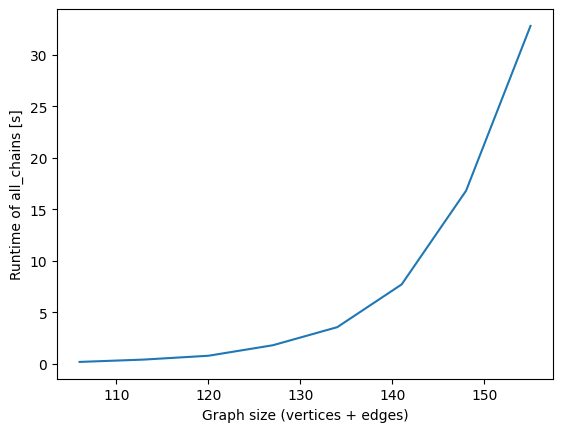

In [8]:
from time import time
import matplotlib.pyplot as plt

sizes = []
times = []
for n in range(15, 23):  # Number of diamonds
    print("="*20)
    print(f"{n} diamonds")
    graph_str = ["X1"]
    for i in range(n):
        k = i*3 + 2
        graph_str.append(f" -> (X{k}, X{k+1}) -> X{k+2}")
    g = parse_graph("".join(graph_str))
    n_vertices = len(g.V)
    n_edges = sum(len(v.children | v.parents) for v in g.V.values()) // 2  # Handshake lemma
    size = n_vertices + n_edges
    sizes.append(size)
    print(f"Graph size:\t {size}")

    start_time = time()
    all_chains(g.V["X1"], g.V[f"X{k+2}"])
    run_time = time() - start_time
    times.append(run_time)
    print(f"Time [s]:\t {run_time:.2f}")

plt.figure()
plt.plot(sizes, times)
plt.xlabel("Graph size (vertices + edges)")
plt.ylabel("Runtime of all_chains [s]")
plt.show()

As we can see, the runtime approximately doubles each time we append a new diamond.

### The Bayes-Ball Algorithm
Previously, we have implemented methods for testing d-separation for specified node groups $A$, $B$ and $C$. What if we only have $A$ and $C$, and want to find the largest set of nodes $B$ which is d-separated from $A$, by $C$? For this, we can use the _Bayes-ball algorithm_. Despite completing a bigger task than `d_sep`, its runtime is _linear_ in the size of the graph.

The core idea is that a ball is thrown from all nodes in $A$ to its children and parents. Whenever a regular node receives a ball from a parent, it will pass it to all of its its children. But if that node was in $C$, it will instead deflect the ball back to its parents. When a regular node receives a ball from one of its children instead, it will send it to both its children and parents. But if that node was in $C$, it will instead do nothing. When ensuring that no throw is performed more than once, the algorithm will terminate.

The algorithm proceeds as follows (adapted from [1]):
>1. Initialize all nodes as neither visited, nor marked on the top, nor marked on the bottom.
>2. Create a schedule of nodes to be visited, initialized with each node in $A$ to be visited as if from one of its children.
>3. While there are still nodes scheduled to be visited:
>    1. Pick any node $v$ scheduled to be visited and remove it from the schedule. Either $v$ was scheduled for a visit from a parent, a visit from a child, or both.
>    2. Mark $v$ as visited.
>    3. If $v \not\in C$ and the visit to $v$ is from a child:
>        1. if the top of $v$ is not marked, then mark its top and schedule each of its parents to be visited;
>        2. if the bottom of $v$ is not marked, then mark its bottom and schedule each of its children (if any) to be visited.
>    4. If the visit to $v$ is from a parent:
>        1. If $v \in C$ and the top of $v$ is not marked, then mark its top and schedule each of its parents to be visited;
>        2. if $v \not\in C$ and the bottom of $v$ is not marked, then mark its bottom and schedule each of its children to be visited.

Once the algorithm finishes, the nodes which are not marked on the bottom (i.e. have never sent the ball to their children), constitutes the set $B$ of nodes that are d-separated from $A$, by $C$.

#### Question 6 (*)
(a) Implement the Bayes-ball algorithm. You can use a queue to create the schedule, by importing `from collections import deque`. A `deque` is a double-ended queue, for which it is cheap to `append` and `pop` from the right and the left (with `appendleft` and `popleft`).<br>
(b) Test the algorithm on the cardiovascular disease graph.<br>
(c) Write a function `d_sep_fast`, which performs the same task as `d_sep`, but internally makes use of `bayes_ball`. Compare its runtime to that of `d_sep`.

In [9]:
from collections import deque

def bayes_ball(g: DAG, A: set[str], C: set[str]) -> set[DAGNode]:
    visited, top_mark, bottom_mark = set(), set(), set()
    Q = deque((v,0) for v in [g.V[a] for a in A])
    while Q:
        v, k = Q.popleft()  # k = 0: visit from child; k = 1: visit from parent
        visited.add(v)
        if v.name not in C and k == 0:
            if v not in top_mark:
                top_mark.add(v)
                Q += [(u, 0) for u in v.parents]
            if v not in bottom_mark:
                bottom_mark.add(v)
                Q += [(u, 1) for u in v.children]
        if k == 1:
            if v.name in C and v not in top_mark:
                top_mark.add(v)
                Q += [(u, 0) for u in v.parents]
            if v.name not in C and v not in bottom_mark:
                bottom_mark.add(v)
                Q += [(u, 1) for u in v.children]
    B = set(g.V.values()).difference(bottom_mark)
    return B

b)

In [10]:
bayes_ball(g_cvd, set(["smoker"]), set())

{<age>, <bp_med>, <chronic_condition>, <hypertension>, <obesity>, <sex>}

In [11]:
bayes_ball(g_cvd, set(["smoker"]), set(["high_chol"]))

{<high_chol>, <obesity>}

c)

In [12]:
def d_sep_fast(g: DAG, A: Collection[str], B: Collection[str], C: Collection[str]) -> bool:
    return set(g.V[b] for b in B) <= bayes_ball(g, A, C)

## References
[1] Ross D. Shachter. _Bayes-Ball: The Rational Pastime (for Determining Irrelevance and Requisite Information in Belief Networks and Influence Diagrams)_ (arXiv: https://arxiv.org/pdf/1301.7412)